# Train TabR dari POC-ABS flatten ordered v16

- sumber: `output/apex/features/poc_abs_flatten_ordered.xlsx`
- semua row frame dipakai sebagai sampel
- external test: 20 `event_clip` tiap label
- output run: `output/apex/train/t1`, `t2`, dst
- hyperparameter final mengikuti hasil tuning v14
- dataset train diratakan: jumlah clip per label dibuat sama


## v16 train clip balance antar label\n

Internal validation tetap di-split berdasarkan `event_clip`, dan data train diratakan agar jumlah clip per label sama antar label sebelum training.

In [1]:
import os
import re
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == 'preprocess-anxiety':
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f'Project root: {ROOT}')


Project root: /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st


In [2]:
import random

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import optuna
import pandas as pd
import seaborn as sns
import torch
from joblib import dump
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger, TensorBoardLogger

from core.data_module import TabRDataModule
from core.TabR import LitTabR


In [3]:
FEATURES_PATH = ROOT / 'output/apex/features/poc_abs_flatten_ordered.xlsx'
TRAIN_ROOT = ROOT / 'output/apex/train'
N_EXTERNAL_PER_LABEL = 20
BATCH_SIZE = 128
MAX_EPOCHS = 50
RANDOM_SEED = 42
THRESHOLD = 0.5
LR = 5.216476754618595e-4
FREEZE_CONTEXT_EPOCH = 16
M_NEIGHBORS = 8
D_MODEL = 256
DROPOUT = 0.15858376130071722
EARLY_STOPPING_PATIENCE = 10

TRAIN_ROOT.mkdir(parents=True, exist_ok=True)
print(FEATURES_PATH)
print(TRAIN_ROOT)
print({
    'lr': LR,
    'freeze_context_epoch': FREEZE_CONTEXT_EPOCH,
    'm_neighbors': M_NEIGHBORS,
    'd_model': D_MODEL,
    'dropout': DROPOUT,
    'patience': EARLY_STOPPING_PATIENCE,
})


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/features/poc_abs_flatten_ordered.xlsx
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train
{'lr': 0.0005216476754618595, 'freeze_context_epoch': 16, 'm_neighbors': 8, 'd_model': 256, 'dropout': 0.15858376130071722, 'patience': 10}


In [4]:
def get_next_train_dir(train_root: Path) -> Path:
    existing = []
    for path in train_root.iterdir():
        if path.is_dir() and re.fullmatch(r't\d+', path.name):
            existing.append(int(path.name[1:]))
    next_idx = max(existing, default=0) + 1
    out_dir = train_root / f't{next_idx}'
    out_dir.mkdir(parents=True, exist_ok=False)
    return out_dir


def plot_lightning_metrics(metrics_csv):
    import pandas as pd
    import matplotlib.pyplot as plt

    df = pd.read_csv(metrics_csv)

    if 'epoch' not in df.columns:
        raise ValueError('Kolom epoch tidak ada')

    df_epoch = (
        df.sort_values('step')
          .groupby('epoch', as_index=False)
          .last()
    )

    plt.figure()

    if 'train_loss' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['train_loss'], label='Train Loss')

    if 'val_loss' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['val_loss'], label='Val Loss')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()

    if 'train_acc' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['train_acc'], label='Train Accuracy')

    if 'val_acc' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['val_acc'], label='Val Accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()


def visualize_results(model_dir, class_names=('anxiety_rendah', 'anxiety_tinggi')):
    model_dir = str(model_dir).rstrip('/')

    cm_files = {
        'Internal': os.path.join(model_dir, 'cm_internal.png'),
        'External': os.path.join(model_dir, 'cm_external.png'),
    }

    report_files = {
        'Internal': os.path.join(model_dir, 'report_internal.csv'),
        'External': os.path.join(model_dir, 'report_external.csv'),
    }

    for name, path in cm_files.items():
        if not os.path.exists(path):
            print(f'Missing {path}')
            continue

        img = mpimg.imread(path)
        plt.figure(figsize=(5, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'TabR {name} Confusion Matrix')
        plt.show()

    for name, path in report_files.items():
        if not os.path.exists(path):
            print(f'Missing {path}')
            continue

        df = pd.read_csv(path, index_col=0)
        print(f'\n=== {name.upper()} CLASSIFICATION REPORT ===')
        print(df)


def evaluate_model(model, loader, threshold=0.5):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            prob = torch.softmax(logits, dim=1)[:, 1]
            preds = (prob > threshold).long()
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, sup = precision_recall_fscore_support(y_true, y_pred, average=None)

    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'support': sup,
        'cm': confusion_matrix(y_true, y_pred),
        'report': classification_report(y_true, y_pred, output_dict=True),
    }


def save_confusion_matrix(cm, labels, out_path, title):
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()


def balance_context_by_label(X, y, max_per_class=None):
    idx0 = (y == 0).nonzero(as_tuple=True)[0]
    idx1 = (y == 1).nonzero(as_tuple=True)[0]

    n = min(len(idx0), len(idx1))
    if max_per_class is not None:
        n = min(n, max_per_class)

    idx0 = idx0[torch.randperm(len(idx0))[:n]]
    idx1 = idx1[torch.randperm(len(idx1))[:n]]

    idx = torch.cat([idx0, idx1])
    idx = idx[torch.randperm(len(idx))]
    return X[idx], y[idx]


In [5]:
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.set_float32_matmul_precision('medium')

df = pd.read_excel(FEATURES_PATH)
print(df.shape)
df[['phase', 'label', 'participant', 'clip', 'event_clip', 'frame']].head()


(57656, 405)


,phase,label,participant,clip,event_clip,frame
0,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,2
1,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,3
2,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,4
3,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,5
4,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,6


In [6]:
label_map = {
    'anxiety_rendah': 0,
    'anxiety_tinggi': 1,
}

df = df[df['label'].isin(label_map)].copy()
df['target'] = df['label'].map(label_map)
df['event_id'] = df['phase'].astype(str) + '||' + df['participant'].astype(str) + '||' + df['question'].astype(str) + '||' + df['clip'].astype(str) + '||' + df['event_clip'].astype(str)

event_table = df[['event_id', 'label', 'target', 'phase', 'participant', 'question', 'clip', 'event_clip']].drop_duplicates().reset_index(drop=True)
event_table.shape


(2763, 8)

In [7]:
def balanced_external_events(event_table: pd.DataFrame, n_per_label: int, seed: int = 42) -> set[str]:
    rng = random.Random(seed)
    selected_ids: list[str] = []

    for label_name in ['anxiety_rendah', 'anxiety_tinggi']:
        label_df = event_table[event_table['label'] == label_name].copy()
        if label_df.empty:
            continue

        picked_rows = []
        used_ids = set()

        participant_groups = []
        for participant, part_df in label_df.groupby('participant', sort=True):
            part_df = part_df.sort_values(['phase', 'question', 'clip', 'event_clip'], kind='stable')
            phase_groups = []
            for phase, phase_df in part_df.groupby('phase', sort=True):
                phase_groups.append(phase_df.to_dict('records'))
            participant_groups.append((participant, phase_groups))

        while len(picked_rows) < n_per_label:
            progress = False
            for _participant, phase_groups in participant_groups:
                for records in phase_groups:
                    while records and records[0]['event_id'] in used_ids:
                        records.pop(0)
                    if not records:
                        continue
                    row = records.pop(0)
                    picked_rows.append(row)
                    used_ids.add(row['event_id'])
                    progress = True
                    if len(picked_rows) >= n_per_label:
                        break
                if len(picked_rows) >= n_per_label:
                    break
            if not progress:
                break

        if len(picked_rows) < n_per_label:
            remaining = label_df[~label_df['event_id'].isin(used_ids)].sort_values(['participant', 'phase', 'question', 'clip', 'event_clip'], kind='stable')
            for row in remaining.to_dict('records'):
                picked_rows.append(row)
                used_ids.add(row['event_id'])
                if len(picked_rows) >= n_per_label:
                    break

        selected_ids.extend([row['event_id'] for row in picked_rows[:n_per_label]])

    return set(selected_ids)


external_event_ids = balanced_external_events(event_table, N_EXTERNAL_PER_LABEL, seed=RANDOM_SEED)
df_external = df[df['event_id'].isin(external_event_ids)].copy()
df_train_all = df[~df['event_id'].isin(external_event_ids)].copy()

print('External events:', len(external_event_ids))
print('External rows:', df_external.shape)
print('Train rows:', df_train_all.shape)
print(event_table[event_table['event_id'].isin(external_event_ids)]['label'].value_counts().to_dict())
print(event_table[event_table['event_id'].isin(external_event_ids)].groupby('label')['participant'].nunique())
print(pd.crosstab(event_table[event_table['event_id'].isin(external_event_ids)]['phase'], event_table[event_table['event_id'].isin(external_event_ids)]['label']))


External events: 40
External rows: (906, 407)
Train rows: (56750, 407)
{'anxiety_tinggi': 20, 'anxiety_rendah': 20}
label
anxiety_rendah    15
anxiety_tinggi    14
Name: participant, dtype: int64
label   anxiety_rendah  anxiety_tinggi
phase                                 
after               14               7
before               6              13


In [8]:
def balance_train_clips_by_label(df_train: pd.DataFrame, seed: int = 42):
    rng = random.Random(seed)
    event_table_train = (
        df_train[['event_id', 'label', 'target', 'phase', 'participant', 'question', 'clip', 'event_clip']]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    grouped = {}
    for label_name, label_df in event_table_train.groupby('label', sort=True):
        clip_table = (
            label_df[['participant', 'question', 'clip', 'label']]
            .drop_duplicates()
            .sort_values(['participant', 'question', 'clip'], kind='stable')
            .reset_index(drop=True)
        )
        grouped[label_name] = clip_table

    min_clip_count = min(len(clip_table) for clip_table in grouped.values())
    selected_clip_keys = []
    clip_balance_rows = []

    for label_name, clip_table in grouped.items():
        clip_records = clip_table.to_dict('records')
        rng.shuffle(clip_records)
        chosen = clip_records[:min_clip_count]
        clip_balance_rows.extend(chosen)
        selected_clip_keys.extend([
            (row['participant'], row['question'], row['clip'], row['label'])
            for row in chosen
        ])

    selected_clip_keys = set(selected_clip_keys)
    df_balanced = df_train[
        df_train.apply(
            lambda row: (row['participant'], row['question'], row['clip'], row['label']) in selected_clip_keys,
            axis=1,
        )
    ].copy()

    clip_balance_df = pd.DataFrame(clip_balance_rows)
    return df_balanced, clip_balance_df


df_train_all_balanced, train_clip_balance = balance_train_clips_by_label(df_train_all, seed=RANDOM_SEED)
train_event_table_balanced = (
    df_train_all_balanced[['event_id', 'label', 'target']]
    .drop_duplicates()
    .reset_index(drop=True)
)

print('Train rows before balance:', df_train_all.shape)
print('Train rows after balance:', df_train_all_balanced.shape)
print('Balanced clips per label:')
print(train_clip_balance['label'].value_counts())
print('Balanced events per label:')
print(train_event_table_balanced['label'].value_counts())



Train rows before balance: (56750, 407)
Train rows after balance: (48217, 407)
Balanced clips per label:
label
anxiety_rendah    160
anxiety_tinggi    160
Name: count, dtype: int64
Balanced events per label:
label
anxiety_tinggi    1235
anxiety_rendah    1112
Name: count, dtype: int64


In [9]:
meta_cols = [
    'phase', 'condition', 'label', 'participant', 'participant_raw', 'question', 'question_no',
    'sample', 'clip', 'event_clip', 'event_no', 'clip_path', 'frame', 'target', 'event_id',
]
feature_cols = [c for c in df.columns if c not in meta_cols]
print('n_features =', len(feature_cols))
feature_cols[:10]


n_features = 392


['mulut_x1',
 'mulut_y1',
 'mulut_t1',
 'mulut_m1',
 'mulut_x2',
 'mulut_y2',
 'mulut_t2',
 'mulut_m2',
 'mulut_x3',
 'mulut_y3']

In [10]:
train_events = train_event_table_balanced.copy()
train_event_ids, val_event_ids = train_test_split(
    train_events['event_id'],
    test_size=0.2,
    stratify=train_events['target'],
    random_state=RANDOM_SEED,
)

train_event_ids = set(train_event_ids.tolist())
val_event_ids = set(val_event_ids.tolist())

df_tr = df_train_all_balanced[df_train_all_balanced['event_id'].isin(train_event_ids)].copy()
df_val = df_train_all_balanced[df_train_all_balanced['event_id'].isin(val_event_ids)].copy()

imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train_np = scaler.fit_transform(imputer.fit_transform(df_tr[feature_cols]))
X_val_np = scaler.transform(imputer.transform(df_val[feature_cols]))
X_ext_np = scaler.transform(imputer.transform(df_external[feature_cols]))

X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(df_tr['target'].values, dtype=torch.long)
X_val = torch.tensor(X_val_np, dtype=torch.float32)
y_val = torch.tensor(df_val['target'].values, dtype=torch.long)
X_ext = torch.tensor(X_ext_np, dtype=torch.float32)
y_ext = torch.tensor(df_external['target'].values, dtype=torch.long)

ctx_train_X, ctx_train_y = balance_context_by_label(X_train, y_train)
ctx_val_X, ctx_val_y = X_val, y_val

print('train events:', len(train_event_ids))
print('val events:', len(val_event_ids))
print(X_train.shape, X_val.shape, X_ext.shape)


train events: 1877
val events: 470
torch.Size([38403, 392]) torch.Size([9814, 392]) torch.Size([906, 392])


In [11]:
def train_tabr_from_dataframe(out_dir: Path):
    dm = TabRDataModule(
        X_train, y_train,
        X_val, y_val,
        ctx_train_X, ctx_train_y,
        ctx_val_X, ctx_val_y,
        batch_size=BATCH_SIZE,
    )

    model = LitTabR(
        in_dim=len(feature_cols),
        num_classes=2,
        d=D_MODEL,
        freeze_context_epoch=FREEZE_CONTEXT_EPOCH,
        m=M_NEIGHBORS,
        lr=LR,
        dropout=DROPOUT,
    )

    checkpoint_cb = ModelCheckpoint(
        dirpath=str(out_dir),
        filename='best',
        monitor='val_loss',
        mode='min',
        save_top_k=1,
    )

    loggers = [
        CSVLogger(save_dir=str(out_dir), name='tabr_logs'),
        TensorBoardLogger(save_dir=str(out_dir), name='tb_logs'),
    ]

    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator='gpu' if torch.cuda.is_available() else 'cpu',
        devices=1,
        logger=loggers,
        log_every_n_steps=1,
        default_root_dir=str(out_dir),
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE, mode='min'),
            checkpoint_cb,
        ],
    )

    trainer.fit(model, datamodule=dm)

    best_ckpt = checkpoint_cb.best_model_path or str(out_dir / 'best.ckpt')
    if checkpoint_cb.best_model_path:
        model = LitTabR.load_from_checkpoint(checkpoint_cb.best_model_path, weights_only=False).to(model.get_device())
    trainer.save_checkpoint(str(out_dir / 'last.ckpt'))

    model.set_preprocessor(imputer=imputer, scaler=scaler, feature_cols=feature_cols)
    model.set_default_context(ctx_train_X, ctx_train_y)

    dump(imputer, out_dir / 'imputer.joblib')
    dump(scaler, out_dir / 'scaler.joblib')
    dump(feature_cols, out_dir / 'feature_cols.joblib')
    dump((ctx_train_X.cpu(), ctx_train_y.cpu()), out_dir / 'context.joblib')
    df_tr.to_csv(out_dir / 'train_split.csv', index=False)
    df_val.to_csv(out_dir / 'val_split.csv', index=False)
    df_external.to_csv(out_dir / 'external_test.csv', index=False)
    pd.DataFrame([{
        'lr': LR,
        'freeze_context_epoch': FREEZE_CONTEXT_EPOCH,
        'm_neighbors': M_NEIGHBORS,
        'd_model': D_MODEL,
        'dropout': DROPOUT,
        'patience': EARLY_STOPPING_PATIENCE,
        'best_checkpoint': best_ckpt,
    }]).to_csv(out_dir / 'run_config.csv', index=False)

    print('INTERNAL')
    model.eval()
    model.set_context(ctx_train_X, ctx_train_y)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
    res_int = evaluate_model(model, val_loader, threshold=THRESHOLD)

    print('EXTERNAL')
    ext_loader = DataLoader(TensorDataset(X_ext, y_ext), batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
    res_ext = evaluate_model(model, ext_loader, threshold=THRESHOLD)

    pd.DataFrame(res_int['report']).transpose().to_csv(out_dir / 'report_internal.csv')
    pd.DataFrame(res_ext['report']).transpose().to_csv(out_dir / 'report_external.csv')

    save_confusion_matrix(res_int['cm'], ['anxiety_rendah', 'anxiety_tinggi'], out_dir / 'cm_internal.png', 'TabR Internal Confusion Matrix')
    save_confusion_matrix(res_ext['cm'], ['anxiety_rendah', 'anxiety_tinggi'], out_dir / 'cm_external.png', 'TabR External Confusion Matrix')

    pd.DataFrame({
        'split': ['internal', 'external'],
        'accuracy': [res_int['accuracy'], res_ext['accuracy']],
    }).to_csv(out_dir / 'summary_metrics.csv', index=False)

    return model, {'internal': res_int, 'external': res_ext}



In [12]:
OUT_DIR = get_next_train_dir(TRAIN_ROOT)
print(OUT_DIR)
model, results = train_tabr_from_dataframe(OUT_DIR)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t37


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t37 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | encoder   | TabREncoder      | 100 K  | train | 0    
1 | WK        | Linear           | 65.5 K | train | 0    
2 | WY        | Embedding        | 512    | train | 0    
3 | T         | ValueCorrection  | 131 K  | train | 0    
4 | predictor | Sequential       | 132 K  | train | 0    
5 | head      | Linear           | 514    | train | 0    
6 | loss_fn   | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
430 K     Trainable params
0         Non-trainable params
430 K     Total params
1.721     Total esti

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Validation context frozen & FAISS built


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`weights_only` was not set, defaulting to `False`.


INTERNAL
EXTERNAL


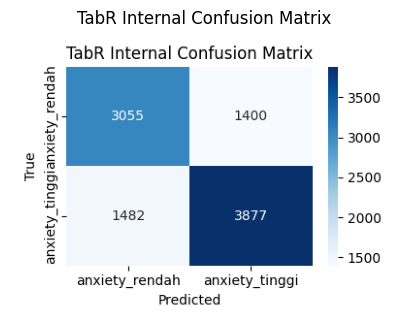

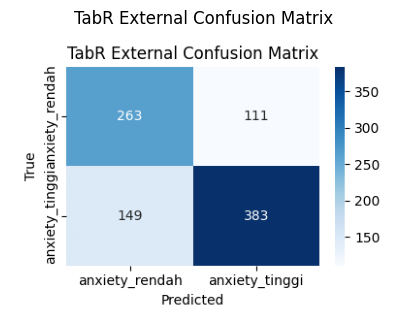


=== INTERNAL CLASSIFICATION REPORT ===
              precision    recall  f1-score      support
0              0.673352  0.685746  0.679493  4455.000000
1              0.734698  0.723456  0.729033  5359.000000
accuracy       0.706338  0.706338  0.706338     0.706338
macro avg      0.704025  0.704601  0.704263  9814.000000
weighted avg   0.706850  0.706338  0.706545  9814.000000

=== EXTERNAL CLASSIFICATION REPORT ===
              precision    recall  f1-score     support
0              0.638350  0.703209  0.669211  374.000000
1              0.775304  0.719925  0.746589  532.000000
accuracy       0.713024  0.713024  0.713024    0.713024
macro avg      0.706827  0.711567  0.707900  906.000000
weighted avg   0.718768  0.713024  0.714647  906.000000


In [13]:
visualize_results(OUT_DIR)


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t37/tabr_logs/version_0/metrics.csv


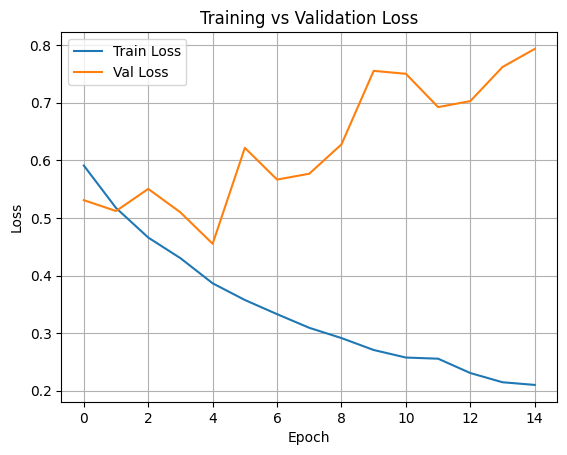

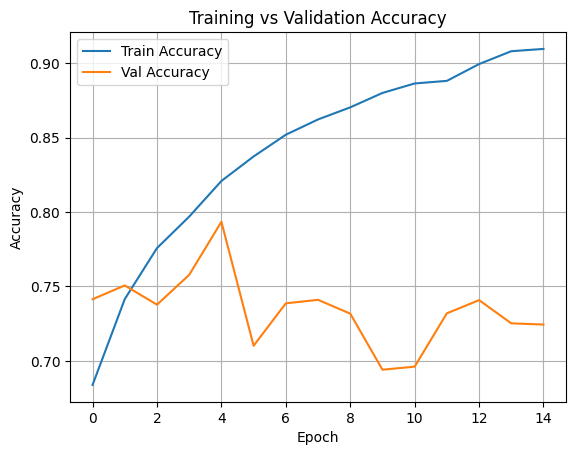

In [14]:
metrics_csv = sorted((OUT_DIR / 'tabr_logs').glob('version_*/metrics.csv'))[-1]
print(metrics_csv)
plot_lightning_metrics(metrics_csv)


In [15]:
print('Internal CM:')
print(results['internal']['cm'])
print('External CM:')
print(results['external']['cm'])


Internal CM:
[[3055 1400]
 [1482 3877]]
External CM:
[[263 111]
 [149 383]]


In [16]:
external_event_table = event_table[event_table['event_id'].isin(external_event_ids)].sort_values(['label', 'phase', 'participant', 'question', 'clip', 'event_clip'], kind='stable')
external_event_table.head(50)


,event_id,label,target,phase,participant,question,clip,event_clip
1437,after||abdul_aziz||q1||answer_1_15d591ce-051a-...,anxiety_rendah,0,after,abdul_aziz,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00006-00024
1462,after||achmad_anfasa_rabbany||q1||answer_1_15d...,anxiety_rendah,0,after,achmad_anfasa_rabbany,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00044-00076
1511,after||ahmad_rifqi_hendriansyah||q1||answer_1_...,anxiety_rendah,0,after,ahmad_rifqi_hendriansyah,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00089-00094
1536,after||aida_rahma_fadhila||q1||answer_1_15d591...,anxiety_rendah,0,after,aida_rahma_fadhila,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00119-00135
1561,after||akhmad_aakhif_athallah||q1||answer_1_15...,anxiety_rendah,0,after,akhmad_aakhif_athallah,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00217-00239
1611,after||aryan_saputra_rahmad||q1||answer_1_15d5...,anxiety_rendah,0,after,aryan_saputra_rahmad,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00007-00018
1636,after||ashrul_rifki_ardiyhasa||q1||answer_1_15...,anxiety_rendah,0,after,ashrul_rifki_ardiyhasa,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00001-00021
1661,after||ayleen_ruhul_qisthy||q1||answer_1_15d59...,anxiety_rendah,0,after,ayleen_ruhul_qisthy,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00159-00195
1685,after||billy_maulana_ferdinan||q1||answer_1_15...,anxiety_rendah,0,after,billy_maulana_ferdinan,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00014-00026
1809,after||ericha_rizki_wardani||q1||answer_1_15d5...,anxiety_rendah,0,after,ericha_rizki_wardani,q1,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00006-00013


In [17]:
print('=== ROW DISTRIBUTION ===')
print('train rows by label')
print(df_tr['label'].value_counts(dropna=False).sort_index())
print()
print('val rows by label')
print(df_val['label'].value_counts(dropna=False).sort_index())
print()
print('external rows by label')
print(df_external['label'].value_counts(dropna=False).sort_index())
print()
print('=== EVENT DISTRIBUTION ===')
print('train events by label')
print(df_tr[['event_id', 'label']].drop_duplicates()['label'].value_counts(dropna=False).sort_index())
print()
print('val events by label')
print(df_val[['event_id', 'label']].drop_duplicates()['label'].value_counts(dropna=False).sort_index())
print()
print('external events by label')
print(df_external[['event_id', 'label']].drop_duplicates()['label'].value_counts(dropna=False).sort_index())
print()
print('=== PHASE DISTRIBUTION ===')
print('train phase x label')
print(pd.crosstab(df_tr['phase'], df_tr['label']))
print()
print('val phase x label')
print(pd.crosstab(df_val['phase'], df_val['label']))
print()
print('external phase x label')
print(pd.crosstab(df_external['phase'], df_external['label']))
print()
print('=== PARTICIPANT DISTRIBUTION ===')
print('train unique participants by label')
print(df_tr.groupby('label')['participant'].nunique())
print()
print('val unique participants by label')
print(df_val.groupby('label')['participant'].nunique())
print()
print('external unique participants by label')
print(df_external.groupby('label')['participant'].nunique())


=== ROW DISTRIBUTION ===
train rows by label
label
anxiety_rendah    16847
anxiety_tinggi    21556
Name: count, dtype: int64

val rows by label
label
anxiety_rendah    4455
anxiety_tinggi    5359
Name: count, dtype: int64

external rows by label
label
anxiety_rendah    374
anxiety_tinggi    532
Name: count, dtype: int64

=== EVENT DISTRIBUTION ===
train events by label
label
anxiety_rendah    889
anxiety_tinggi    988
Name: count, dtype: int64

val events by label
label
anxiety_rendah    223
anxiety_tinggi    247
Name: count, dtype: int64

external events by label
label
anxiety_rendah    20
anxiety_tinggi    20
Name: count, dtype: int64

=== PHASE DISTRIBUTION ===
train phase x label
label   anxiety_rendah  anxiety_tinggi
phase                                 
after            10681            7551
before            6166           14005

val phase x label
label   anxiety_rendah  anxiety_tinggi
phase                                 
after             3078            1939
before         

In [18]:
print('=== INTERNAL WITH VAL CONTEXT ===')
model.eval()
model.set_context(ctx_val_X, ctx_val_y)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
res_internal_val_ctx = evaluate_model(model, val_loader, threshold=THRESHOLD)
print(pd.DataFrame(res_internal_val_ctx['report']).transpose())
print(res_internal_val_ctx['cm'])
print()
print('=== INTERNAL WITH TRAIN CONTEXT ===')
model.set_context(ctx_train_X, ctx_train_y)
res_internal_train_ctx = evaluate_model(model, val_loader, threshold=THRESHOLD)
print(pd.DataFrame(res_internal_train_ctx['report']).transpose())
print(res_internal_train_ctx['cm'])


=== INTERNAL WITH VAL CONTEXT ===
              precision    recall  f1-score     support
0              0.657847  0.904153  0.761581  4455.00000
1              0.884313  0.609069  0.721326  5359.00000
accuracy       0.743020  0.743020  0.743020     0.74302
macro avg      0.771080  0.756611  0.741453  9814.00000
weighted avg   0.781511  0.743020  0.739599  9814.00000
[[4028  427]
 [2095 3264]]

=== INTERNAL WITH TRAIN CONTEXT ===
              precision    recall  f1-score      support
0              0.673352  0.685746  0.679493  4455.000000
1              0.734698  0.723456  0.729033  5359.000000
accuracy       0.706338  0.706338  0.706338     0.706338
macro avg      0.704025  0.704601  0.704263  9814.000000
weighted avg   0.706850  0.706338  0.706545  9814.000000
[[3055 1400]
 [1482 3877]]
